In [41]:
!pip install catboost

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split

from catboost import CatBoostRegressor

def load_rideshare_data(path: str) -> pd.DataFrame:
    return pd.read_csv(path)


def split_data(df, target='price', test_size=0.2, random_state=42):
    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    return X_train, X_test, y_train, y_test

In [43]:
df = load_rideshare_data("rideshare_feature_engineering.csv")

In [44]:
df.head()

,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,...,log_distance,surge_x_distance,surge_intensity,is_surge,tier_enc,cab_type_enc,route_frequency,name_enc,destination_enc,source_enc
0,9,16,12,5.0,0.44,1.0,42.2148,-71.033,42.34,37.12,...,0.364643,0.44,0.0,0,0,1,8874,7,7,5
1,2,27,11,11.0,0.44,1.0,42.2148,-71.033,43.58,37.35,...,0.364643,0.44,0.0,0,2,1,8874,2,7,5
2,1,28,11,7.0,0.44,1.0,42.2148,-71.033,38.33,32.93,...,0.364643,0.44,0.0,0,1,1,8874,5,7,5
3,4,30,11,26.0,0.44,1.0,42.2148,-71.033,34.38,29.63,...,0.364643,0.44,0.0,0,2,1,8874,4,7,5
4,3,29,11,9.0,0.44,1.0,42.2148,-71.033,37.44,30.88,...,0.364643,0.44,0.0,0,1,1,8874,6,7,5


In [45]:
df.columns

Index(['hour', 'day', 'month', 'price', 'distance', 'surge_multiplier',
       'latitude', 'longitude', 'temperature', 'apparentTemperature',
       'precipIntensity', 'precipProbability', 'humidity', 'windSpeed',
       'windGust', 'visibility', 'temperatureHigh', 'temperatureLow',
       'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint',
       'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone',
       'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax',
       'apparentTemperatureMin', 'apparentTemperatureMax', 'log_distance',
       'surge_x_distance', 'surge_intensity', 'is_surge', 'tier_enc',
       'cab_type_enc', 'route_frequency', 'name_enc', 'destination_enc',
       'source_enc'],
      dtype='object')

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637976 entries, 0 to 637975
Data columns (total 42 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   hour                     637976 non-null  int64  
 1   day                      637976 non-null  int64  
 2   month                    637976 non-null  int64  
 3   price                    637976 non-null  float64
 4   distance                 637976 non-null  float64
 5   surge_multiplier         637976 non-null  float64
 6   latitude                 637976 non-null  float64
 7   longitude                637976 non-null  float64
 8   temperature              637976 non-null  float64
 9   apparentTemperature      637976 non-null  float64
 10  precipIntensity          637976 non-null  float64
 11  precipProbability        637976 non-null  float64
 12  humidity                 637976 non-null  float64
 13  windSpeed                637976 non-null  float64
 14  wind

In [47]:
X_train, X_test, y_train, y_test = split_data(df)

In [48]:
model_configs = [
    {
        "name": "LinearRegression",
        "model": LinearRegression(),
        "params": {}
    },
    {
        "name": "Ridge (Baseline)",
        "model": Ridge(),
        "params": {
            "alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
        }
    },
    {
        "name": "RandomForest",
        "model": RandomForestRegressor(random_state=42, n_jobs=1),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 15, 20],
            "min_samples_leaf": [4, 8],
            "max_samples": [0.4, 0.6],
            "max_features": [0.5, "sqrt"]
        }
    },
    {
        "name": "HistGradientBoosting",
        "model": HistGradientBoostingRegressor(random_state=42),
        "params": {
            "max_iter": [300, 500, 800],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [3, 5, 7]
        }
    },
    {
        "name": "CatBoost",
        "model": CatBoostRegressor(
            verbose=50,
            allow_writing_files=False,
            random_state=42
        ),
        "params": {
            "depth": [4, 6, 8],
            "learning_rate": [0.01, 0.05, 0.1],
            "iterations": [300, 600, 1000]
        }
    }
]

In [49]:
# CV strategy
cv = KFold(n_splits=3, shuffle=True, random_state=42)

def rmse_cv(model, X, y):
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )
    return -scores.mean(), scores.std()


=== MODEL COMPARISON (CV RMSE) ===
Model           RMSE       Std       
LinearRegression 5.0833     0.0108    
Ridge (Baseline) 5.0833     0.0108    


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomForest    1.8270     0.0077    
HistGradientBoosting 1.7034     0.0113    
CatBoost        1.6536     0.0092    


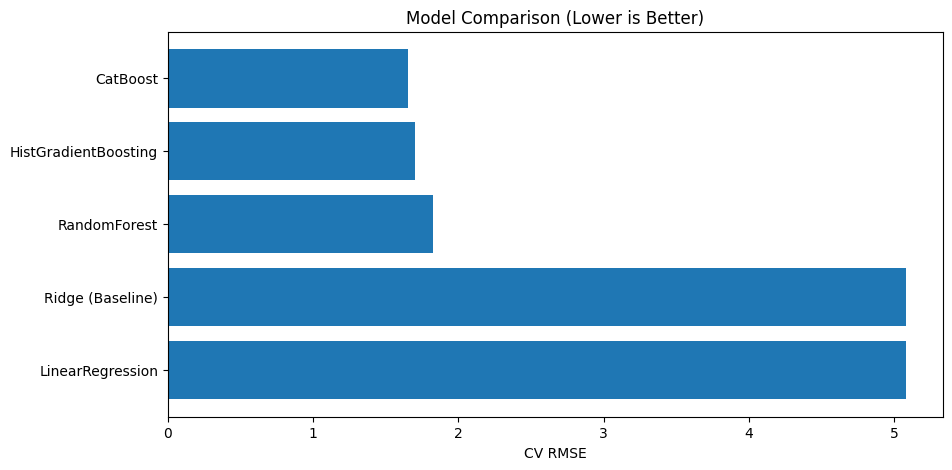

In [50]:
results = []

print("\n=== MODEL COMPARISON (CV RMSE) ===")
print(f"{'Model':<15} {'RMSE':<10} {'Std':<10}")

for cfg in model_configs:
    model = clone(cfg["model"])

    rmse, std = rmse_cv(model, X_train, y_train)

    results.append({
        "Model": cfg["name"],
        "RMSE": rmse,
        "Std": std
    })

    print(f"{cfg['name']:<15} {rmse:<10.4f} {std:<10.4f}")


results_df = pd.DataFrame(results).sort_values("RMSE")

plt.figure(figsize=(10, 5))
plt.barh(results_df["Model"], results_df["RMSE"])
plt.xlabel("CV RMSE")
plt.title("Model Comparison (Lower is Better)")
plt.gca().invert_yaxis()
plt.show()


=== HYPERPARAMETER TUNING (TOP MODELS) ===
Model                     Best RMSE    Best Params
Fitting 3 folds for each of 3 candidates, totalling 9 fits
RandomForest              2.1923       {'n_estimators': 100, 'min_samples_leaf': 4, 'max_samples': 0.4, 'max_features': 'sqrt', 'max_depth': 20}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
HistGradientBoosting      1.6735       {'max_iter': 800, 'max_depth': 7, 'learning_rate': 0.03}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
0:	learn: 8.6180000	total: 146ms	remaining: 2m 26s
50:	learn: 2.3417425	total: 4.05s	remaining: 1m 15s
100:	learn: 1.9238863	total: 8.39s	remaining: 1m 14s
150:	learn: 1.8331226	total: 13.4s	remaining: 1m 15s
200:	learn: 1.7914519	total: 17.1s	remaining: 1m 8s
250:	learn: 1.7656708	total: 21s	remaining: 1m 2s
300:	learn: 1.7486187	total: 26.3s	remaining: 1m 1s
350:	learn: 1.7351928	total: 30.1s	remaining: 55.7s
400:	learn: 1.7253099	total: 33.9s	remaining: 50.7s
450:	learn: 1.717345

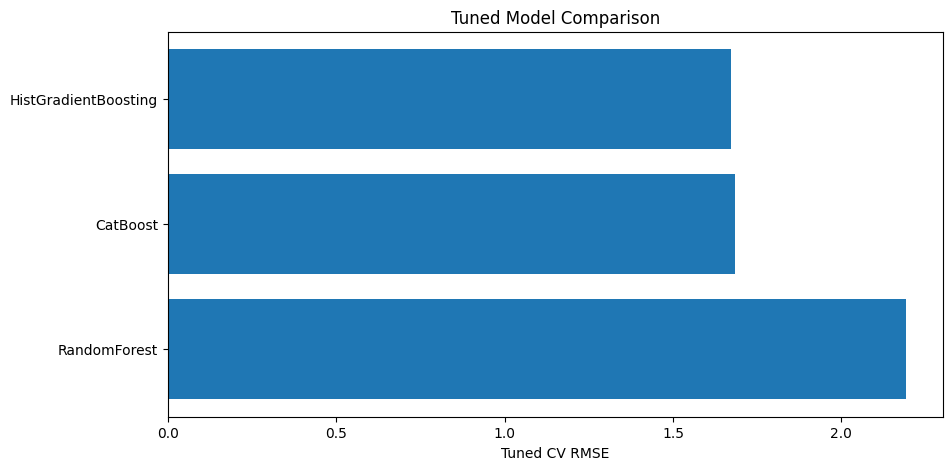

In [51]:
top_models = results_df["Model"].head(3).tolist()

tuned_results = []

print("\n=== HYPERPARAMETER TUNING (TOP MODELS) ===")
print(f"{'Model':<25} {'Best RMSE':<12} {'Best Params'}")

for cfg in model_configs:
    if cfg["name"] not in top_models:
        continue
    if not cfg["params"]:
        continue

    search = RandomizedSearchCV(
        estimator=clone(cfg["model"]),
        param_distributions=cfg["params"],
        n_iter=3,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=1,
        random_state=42,
        verbose=1
    )

    search.fit(X_train, y_train)

    best_rmse = -search.best_score_

    tuned_results.append({
        "Model":         cfg["name"],
        "RMSE":          best_rmse,
        "BestEstimator": search.best_estimator_,
        "BestParams":    search.best_params_   # add this
    })

    print(f"{cfg['name']:<25} {best_rmse:<12.4f} {search.best_params_}")


tuned_df = pd.DataFrame(tuned_results).sort_values("RMSE")

plt.figure(figsize=(10, 5))
plt.barh(tuned_df["Model"], tuned_df["RMSE"])
plt.xlabel("Tuned CV RMSE")
plt.title("Tuned Model Comparison")
plt.gca().invert_yaxis()
plt.show()

In [52]:
best_model = tuned_results[0]["BestEstimator"]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print("\n=== FINAL TEST EVALUATION ===")
print(f"RMSE: {final_rmse:.4f}")
print(f"R2  : {final_r2:.4f}")


=== FINAL TEST EVALUATION ===
RMSE: 2.1299
R2  : 0.9480


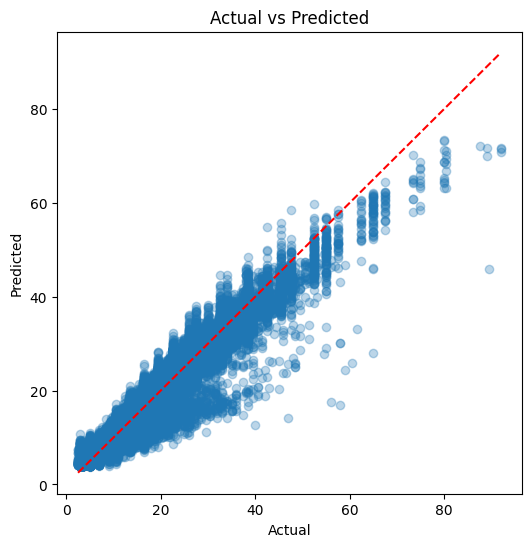

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "--r")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()